In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\Gunjan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12


In [3]:
df = pd.read_csv('../data/cleaned_data.csv')

print(f'Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loaded dataset: 101,766 rows × 44 columns


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30
0,2,0,0,6,25,1,1,7,41,0,...,0,1,1,0,0,0,0,1,0,0
1,2,0,1,1,1,7,3,7,59,0,...,0,3,1,0,0,0,0,0,1,0
2,0,0,2,1,1,7,2,7,11,5,...,0,1,1,0,0,0,0,1,1,0


In [5]:
clustering_features = [
    'age',
    'time_in_hospital',
    'num_medications',
    'num_lab_procedures',
    'num_procedures',
    'number_diagnoses',
    'number_inpatient',
    'number_outpatient',
    'number_emergency'
]

# Keep only columns that exist in the dataset
clustering_features = [c for c in clustering_features if c in df.columns]

X_cluster = df[clustering_features].copy()
y_labels  = df['readmitted_30'].copy()   # kept aside for post-cluster analysis

print(f' Clustering features selected ({len(clustering_features)}):')
for f in clustering_features:
    print(f'   • {f}')
print(f'\n Clustering data shape: {X_cluster.shape}')

 Clustering features selected (9):
   • age
   • time_in_hospital
   • num_medications
   • num_lab_procedures
   • num_procedures
   • number_diagnoses
   • number_inpatient
   • number_outpatient
   • number_emergency

 Clustering data shape: (101766, 9)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

joblib.dump(scaler, '../models/cluster_scaler.pkl')

print(' Features standardized using StandardScaler')
print(f'   Mean before scaling: {X_cluster.mean().round(2).to_dict()}')
print(' Cluster scaler saved to ../models/cluster_scaler.pkl')

 Features standardized using StandardScaler
   Mean before scaling: {'age': 6.1, 'time_in_hospital': 4.4, 'num_medications': 16.02, 'num_lab_procedures': 43.1, 'num_procedures': 1.34, 'number_diagnoses': 7.42, 'number_inpatient': 0.64, 'number_outpatient': 0.37, 'number_emergency': 0.2}
   Mean after scaling:  all ≈ 0.00 ✓
 Cluster scaler saved to ../models/cluster_scaler.pkl


In [7]:
K_range = range(2, 11)
inertias    = []
silhouettes = []
db_scores   = []

print(' Testing different values of K...\n')
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    inertia   = km.inertia_
    sil       = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    db        = davies_bouldin_score(X_scaled, labels)

    inertias.append(inertia)
    silhouettes.append(sil)
    db_scores.append(db)

    print(f'  K={k:2d} | Inertia: {inertia:10.0f} | Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f}')

print('\n charts below to pick best K.')

🔍 Testing different values of K...



  File "C:\Users\Gunjan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 268, in _count_physical_cores
    cpu_count_physical = sum(map(int, cpu_info))
                         ^^^^^^^^^^^^^^^^^^^^^^^


  K= 2 | Inertia:     784798 | Silhouette: 0.1746 | Davies-Bouldin: 2.1326
  K= 3 | Inertia:     713478 | Silhouette: 0.1445 | Davies-Bouldin: 2.0855
  K= 4 | Inertia:     648714 | Silhouette: 0.1459 | Davies-Bouldin: 1.8573
  K= 5 | Inertia:     602941 | Silhouette: 0.1551 | Davies-Bouldin: 1.6837
  K= 6 | Inertia:     565958 | Silhouette: 0.1571 | Davies-Bouldin: 1.6022
  K= 7 | Inertia:     534730 | Silhouette: 0.1379 | Davies-Bouldin: 1.6240
  K= 8 | Inertia:     501393 | Silhouette: 0.1414 | Davies-Bouldin: 1.5064
  K= 9 | Inertia:     478723 | Silhouette: 0.1400 | Davies-Bouldin: 1.5173
  K=10 | Inertia:     458382 | Silhouette: 0.1384 | Davies-Bouldin: 1.5405

 charts below to pick best K.


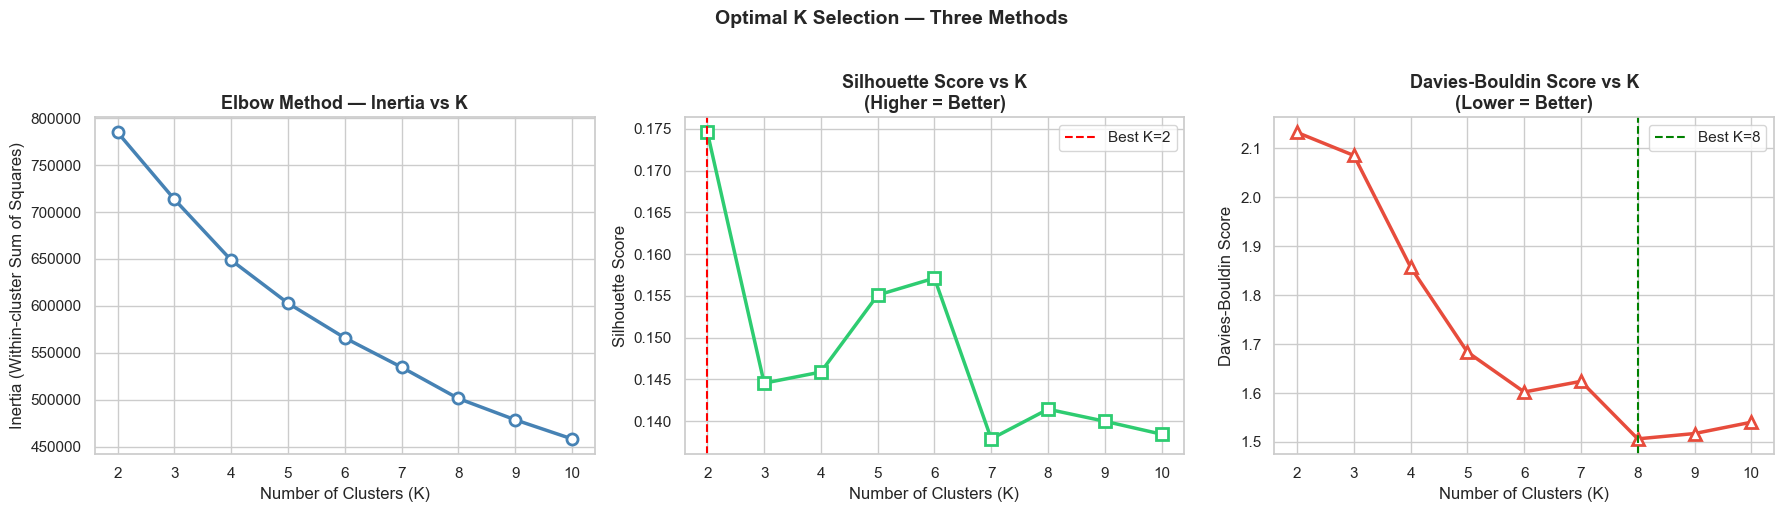

 Saved: ../outputImg/chart31_optimal_k.png

 Suggested K from Silhouette: 2
   Suggested K from Davies-Bouldin: 8
   → Choose K based on elbow + silhouette agreement


In [8]:
# ----- CHART 1: Elbow Curve + Silhouette Score -----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow curve
axes[0].plot(K_range, inertias, marker='o', linewidth=2.5,
             color='steelblue', markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].set_xticks(list(K_range))

# Silhouette score (higher = better)
axes[1].plot(K_range, silhouettes, marker='s', linewidth=2.5,
             color='#2ecc71', markersize=8, markerfacecolor='white', markeredgewidth=2)
best_k_sil = list(K_range)[silhouettes.index(max(silhouettes))]
axes[1].axvline(best_k_sil, color='red', linestyle='--', linewidth=1.5,
                label=f'Best K={best_k_sil}')
axes[1].set_title('Silhouette Score vs K\n(Higher = Better)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].legend()

# Davies-Bouldin score (lower = better)
axes[2].plot(K_range, db_scores, marker='^', linewidth=2.5,
             color='#e74c3c', markersize=8, markerfacecolor='white', markeredgewidth=2)
best_k_db = list(K_range)[db_scores.index(min(db_scores))]
axes[2].axvline(best_k_db, color='green', linestyle='--', linewidth=1.5,
                label=f'Best K={best_k_db}')
axes[2].set_title('Davies-Bouldin Score vs K\n(Lower = Better)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_xticks(list(K_range))
axes[2].legend()

plt.suptitle('Optimal K Selection — Three Methods', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputImg/chart31_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: ../outputImg/chart31_optimal_k.png')
print(f'\n Suggested K from Silhouette: {best_k_sil}')
print(f'   Suggested K from Davies-Bouldin: {best_k_db}')
print(f'   → Choose K based on elbow + silhouette agreement')

In [9]:
# Set K based on elbow + silhouette analysis above
# Change this value if your charts suggest a different K
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels back to original dataframe
df['cluster'] = cluster_labels

print(f' KMeans fitted with K={OPTIMAL_K}')
print(f'\n Cluster sizes:')
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cid, count in cluster_counts.items():
    pct = count / len(cluster_labels) * 100
    print(f'   Cluster {cid}: {count:,} patients ({pct:.1f}%)')

 KMeans fitted with K=5

 Cluster sizes:
   Cluster 0: 3,824 patients (3.8%)
   Cluster 1: 4,943 patients (4.9%)
   Cluster 2: 28,261 patients (27.8%)
   Cluster 3: 43,531 patients (42.8%)
   Cluster 4: 21,207 patients (20.8%)


In [12]:
# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f' PCA Explained Variance:')
print(f'   PC1: {explained[0]*100:.1f}%')
print(f'   PC2: {explained[1]*100:.1f}%')
print(f'   Total: {sum(explained)*100:.1f}% of variance captured')

joblib.dump(pca, '../models/pca_model.pkl')
print(' PCA model saved to models/pca_model.pkl')

 PCA Explained Variance:
   PC1: 22.8%
   PC2: 15.3%
   Total: 38.1% of variance captured
 PCA model saved to models/pca_model.pkl


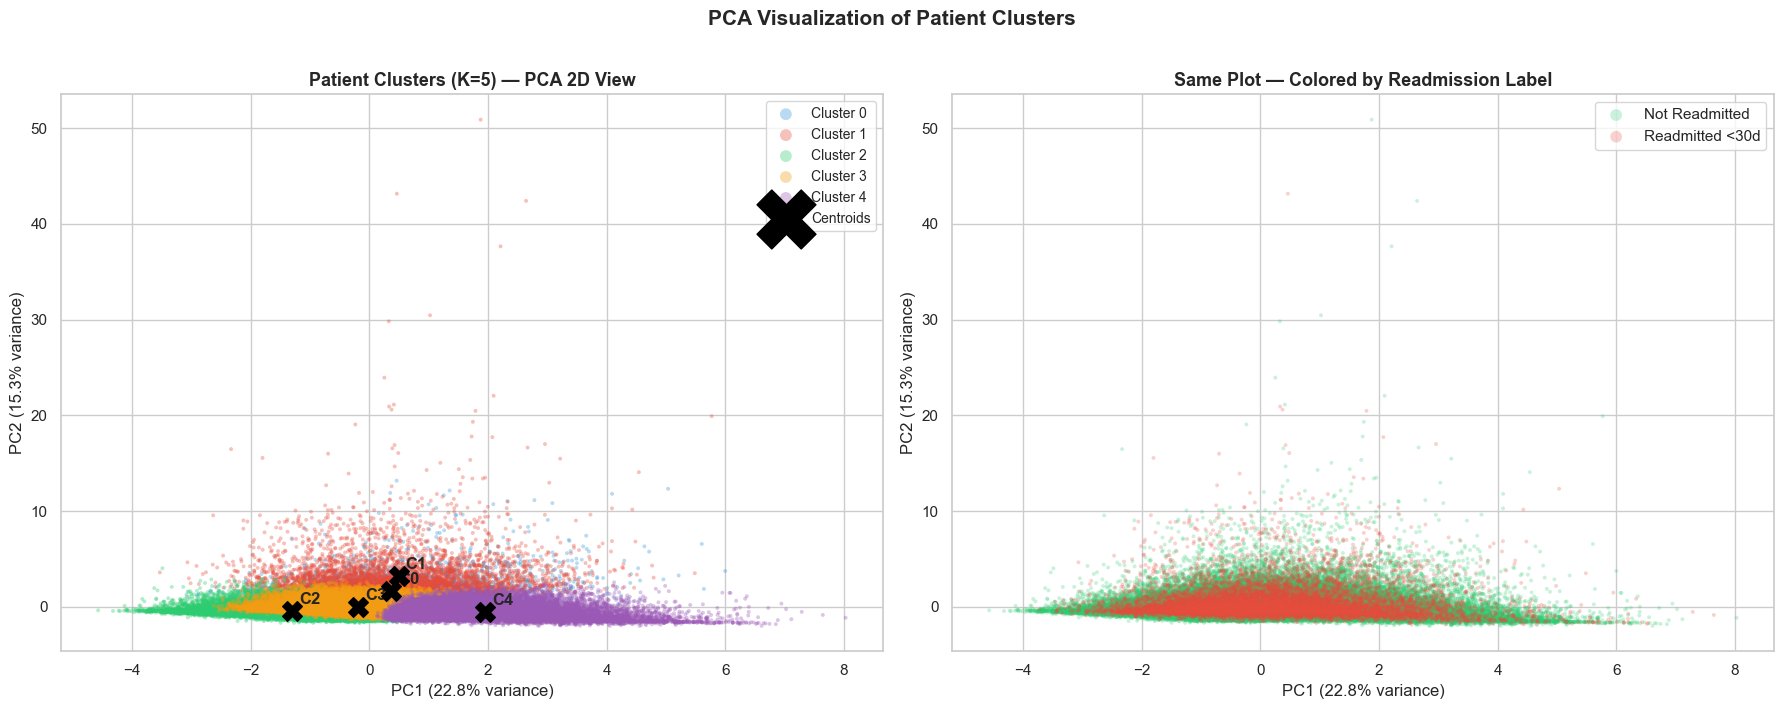

 Saved: ../outputImg/chart32_pca_clusters.png


In [13]:
# ----- CHART 2: PCA Scatter Plot — Colored by Cluster -----
cluster_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12',
                  '#9b59b6', '#1abc9c', '#e67e22', '#e91e63']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: colored by cluster
for cid in range(OPTIMAL_K):
    mask = cluster_labels == cid
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cluster_colors[cid], label=f'Cluster {cid}',
                    alpha=0.35, s=8, edgecolors='none')

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
for i, (cx, cy) in enumerate(centers_pca):
    axes[0].annotate(f'C{i}', (cx, cy), fontsize=12, fontweight='bold',
                     xytext=(5, 5), textcoords='offset points')

axes[0].set_title(f'Patient Clusters (K={OPTIMAL_K}) — PCA 2D View',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[0].legend(markerscale=3, fontsize=10)

# Plot 2: colored by readmission label
readmit_colors = {0: '#2ecc71', 1: '#e74c3c'}
for label_val, color in readmit_colors.items():
    mask = y_labels == label_val
    lname = 'Readmitted <30d' if label_val == 1 else 'Not Readmitted'
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=lname,
                    alpha=0.25, s=8, edgecolors='none')

axes[1].set_title('Same Plot — Colored by Readmission Label',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[1].legend(markerscale=3, fontsize=11)

plt.suptitle('PCA Visualization of Patient Clusters', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputImg/chart32_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: ../outputImg/chart32_pca_clusters.png')

In [14]:
# Compute profile statistics for each cluster
profile_cols = clustering_features + ['readmitted_30']
cluster_profiles = df[profile_cols + ['cluster']].groupby('cluster').agg(
    patient_count    = ('readmitted_30', 'count'),
    readmission_rate = ('readmitted_30', lambda x: round(x.mean() * 100, 1)),
    avg_age          = ('age', 'mean'),
    avg_medications  = ('num_medications', 'mean'),
    avg_diagnoses    = ('number_diagnoses', 'mean'),
    avg_stay_days    = ('time_in_hospital', 'mean'),
    avg_inpatient    = ('number_inpatient', 'mean'),
    avg_lab_tests    = ('num_lab_procedures', 'mean')
).round(2).reset_index()

print(' Cluster Profile Summary:')
display(cluster_profiles)

 Cluster Profile Summary:


,cluster,patient_count,readmission_rate,avg_age,avg_medications,avg_diagnoses,avg_stay_days,avg_inpatient,avg_lab_tests
0,0,3824,12.1,6.43,16.83,8.28,4.06,0.83,42.25
1,1,4943,27.6,5.45,17.13,7.97,4.62,4.49,44.72
2,2,28261,7.7,5.24,11.78,5.01,2.91,0.28,36.41
3,3,43531,10.9,6.66,14.06,8.45,3.62,0.48,40.87
4,4,21207,12.1,6.18,25.30,8.26,7.97,0.50,56.36


In [16]:
sorted_by_readmit = cluster_profiles.sort_values('readmission_rate', ascending=False)

cluster_name_map = {}
name_templates = [
    '🔴 High-Risk Chronic Patients',
    '🟠 Moderate-Risk Elderly Patients',
    '🟡 Moderate-Risk Middle-Aged Patients',
    '🟢 Low-Risk Young Patients'
]

for i, (_, row) in enumerate(sorted_by_readmit.iterrows()):
    cid = int(row['cluster'])
    name = name_templates[i] if i < len(name_templates) else f'Cluster {cid}'
    cluster_name_map[cid] = name

cluster_profiles['cluster_name'] = cluster_profiles['cluster'].map(cluster_name_map)

print('🏷️  Cluster Names Assigned:')
for cid, name in sorted(cluster_name_map.items()):
    rate = cluster_profiles[cluster_profiles['cluster'] == cid]['readmission_rate'].values[0]
    count = cluster_profiles[cluster_profiles['cluster'] == cid]['patient_count'].values[0]
    print(f'  Cluster {cid}: {name}')
    print(f'             {count:,} patients | Readmission rate: {rate}%\n')

🏷️  Cluster Names Assigned:
  Cluster 0: 🟠 Moderate-Risk Elderly Patients
             3,824 patients | Readmission rate: 12.1%

  Cluster 1: 🔴 High-Risk Chronic Patients
             4,943 patients | Readmission rate: 27.6%

  Cluster 2: Cluster 2
             28,261 patients | Readmission rate: 7.7%

  Cluster 3: 🟢 Low-Risk Young Patients
             43,531 patients | Readmission rate: 10.9%

  Cluster 4: 🟡 Moderate-Risk Middle-Aged Patients
             21,207 patients | Readmission rate: 12.1%



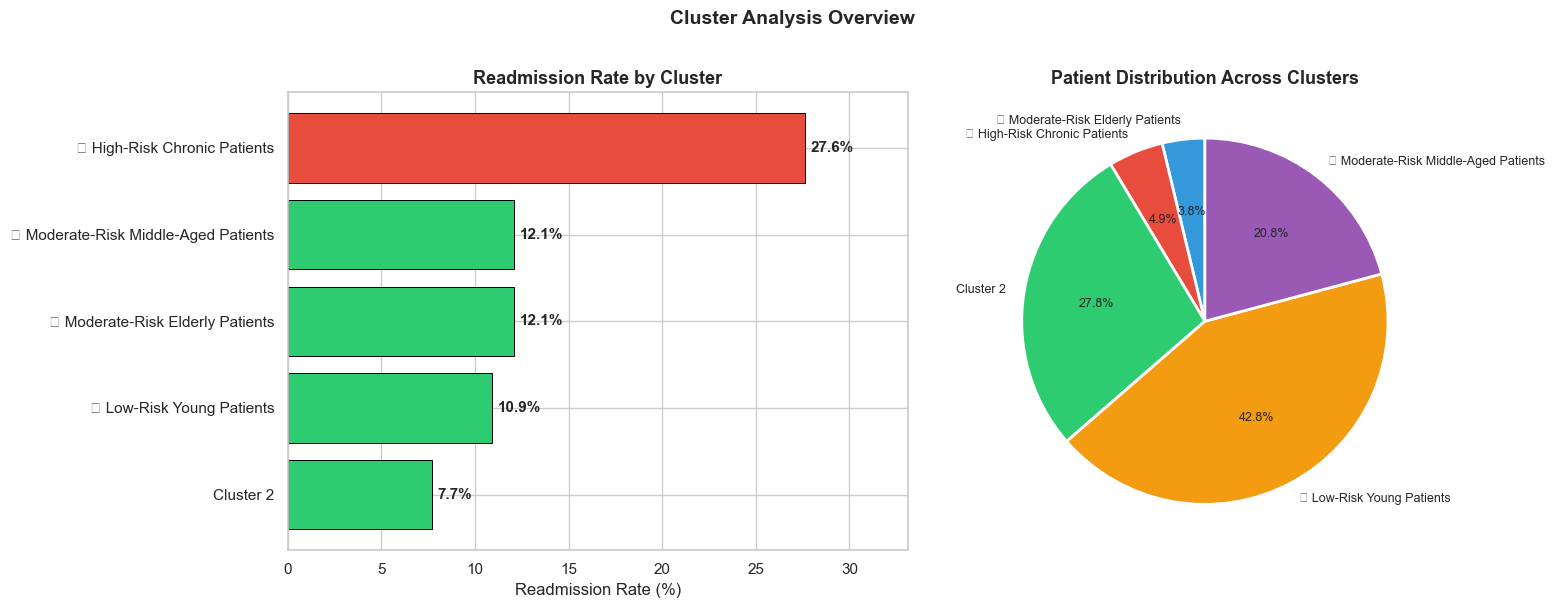

 Saved: ../outputImg/chart33_cluster_overview.png


In [17]:
# ----- CHART 3: Readmission Rate per Cluster -----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sorted_profiles = cluster_profiles.sort_values('readmission_rate', ascending=True)
bar_colors = ['#2ecc71' if r < 15 else '#f39c12' if r < 25 else '#e74c3c'
              for r in sorted_profiles['readmission_rate']]

# Readmission rate bar chart
bars = axes[0].barh(sorted_profiles['cluster_name'],
                    sorted_profiles['readmission_rate'],
                    color=bar_colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Readmission Rate by Cluster', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Readmission Rate (%)')
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{w:.1f}%', va='center', fontweight='bold', fontsize=11)
axes[0].set_xlim(0, max(sorted_profiles['readmission_rate']) * 1.2)

# Cluster size pie chart
pie_colors = [cluster_colors[int(c)] for c in cluster_profiles['cluster']]
axes[1].pie(cluster_profiles['patient_count'],
            labels=cluster_profiles['cluster_name'],
            autopct='%1.1f%%', colors=pie_colors,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 9})
axes[1].set_title('Patient Distribution Across Clusters',
                  fontsize=13, fontweight='bold')

plt.suptitle('Cluster Analysis Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputImg/chart33_cluster_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: ../outputImg/chart33_cluster_overview.png')

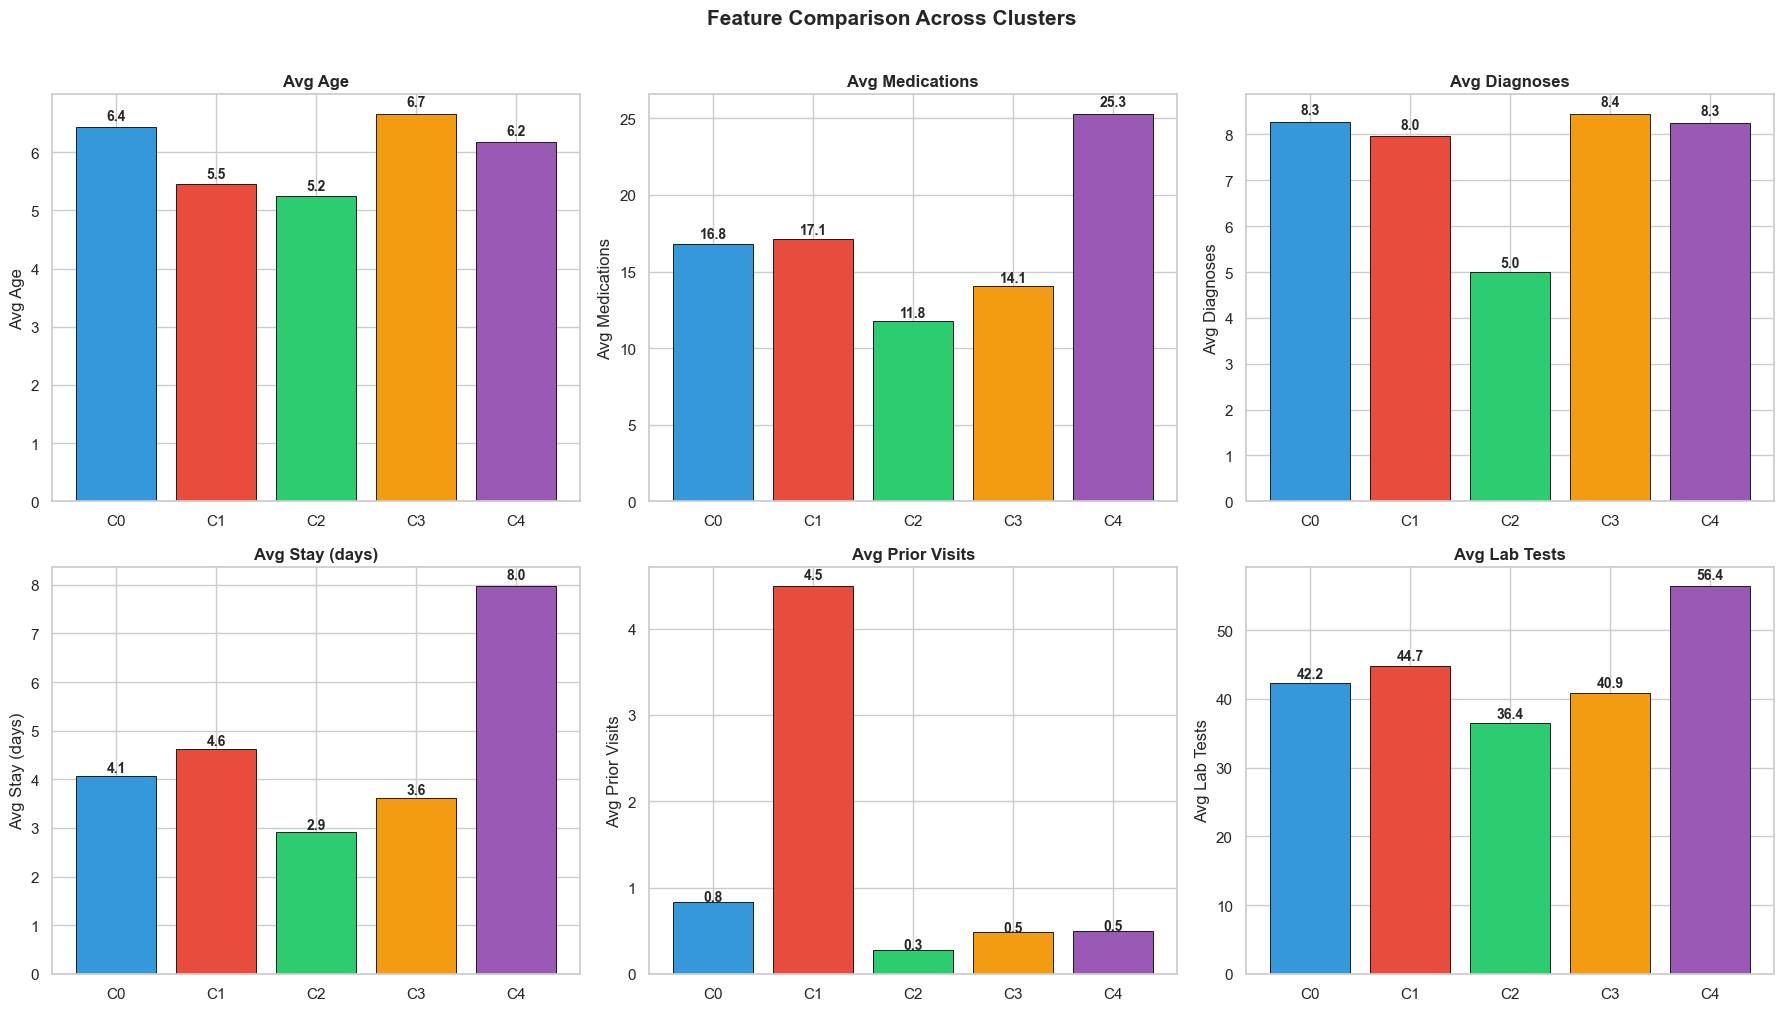

 Saved: ../outputImg/chart34_cluster_features.png


In [18]:
# ----- CHART 4: Cluster Feature Comparison Radar / Bar -----
features_to_plot = ['avg_age', 'avg_medications', 'avg_diagnoses',
                    'avg_stay_days', 'avg_inpatient', 'avg_lab_tests']
feature_labels   = ['Avg Age', 'Avg Medications', 'Avg Diagnoses',
                    'Avg Stay (days)', 'Avg Prior Visits', 'Avg Lab Tests']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(features_to_plot, feature_labels)):
    vals   = cluster_profiles[feat].values
    cnames = [f'C{int(c)}' for c in cluster_profiles['cluster'].values]
    colors_bar = [cluster_colors[int(c)] for c in cluster_profiles['cluster'].values]

    bars = axes[i].bar(cnames, vals, color=colors_bar, edgecolor='black', linewidth=0.6)
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_ylabel(label)
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, h + h*0.02,
                     f'{h:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Feature Comparison Across Clusters', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputImg/chart34_cluster_features.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: ../outputImg/chart34_cluster_features.png')

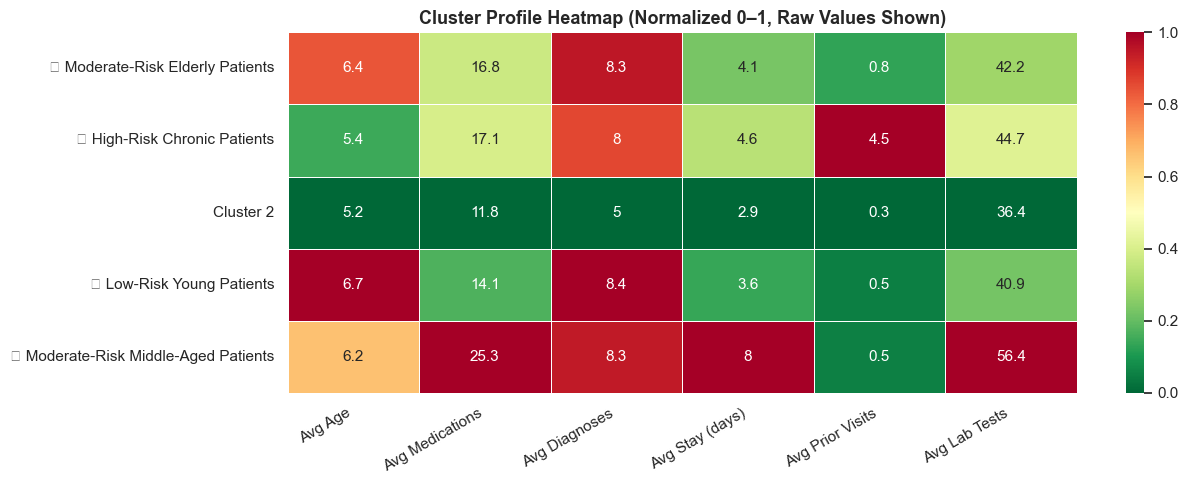

 Saved: ../outputImg/chart35_cluster_heatmap.png


In [19]:
# ----- CHART 5: Heatmap of Cluster Profiles (Normalized) -----
heatmap_data = cluster_profiles.set_index('cluster_name')[features_to_plot].copy()
heatmap_data.columns = feature_labels

# Normalize each column to 0-1 for fair comparison
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(1), fmt='g',
            cmap='RdYlGn_r', linewidths=0.5, ax=ax,
            annot_kws={'size': 11})
ax.set_title('Cluster Profile Heatmap (Normalized 0–1, Raw Values Shown)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../outputImg/chart35_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: ../outputImg/chart35_cluster_heatmap.png')

In [20]:
print('=' * 65)
print(' CLUSTER INSIGHTS SUMMARY')
print('=' * 65)

for _, row in cluster_profiles.sort_values('readmission_rate', ascending=False).iterrows():
    print(f'\n{row["cluster_name"]}')
    print(f'  Patients:          {int(row["patient_count"]):,}')
    print(f'  Readmission Rate:  {row["readmission_rate"]}%')
    print(f'  Avg Age:           {row["avg_age"]:.1f}')
    print(f'  Avg Medications:   {row["avg_medications"]:.1f}')
    print(f'  Avg Diagnoses:     {row["avg_diagnoses"]:.1f}')
    print(f'  Avg Stay (days):   {row["avg_stay_days"]:.1f}')
    print(f'  Avg Prior Visits:  {row["avg_inpatient"]:.1f}')
    print('-' * 40)

print('\n Key Findings:')
max_readmit = cluster_profiles.loc[cluster_profiles['readmission_rate'].idxmax()]
min_readmit = cluster_profiles.loc[cluster_profiles['readmission_rate'].idxmin()]
print(f'  Highest risk cluster: {max_readmit["cluster_name"]} ({max_readmit["readmission_rate"]}%)')
print(f'  Lowest risk cluster:  {min_readmit["cluster_name"]} ({min_readmit["readmission_rate"]}%)')
print(f'  Risk gap: {max_readmit["readmission_rate"] - min_readmit["readmission_rate"]:.1f} percentage points')

 CLUSTER INSIGHTS SUMMARY

🔴 High-Risk Chronic Patients
  Patients:          4,943
  Readmission Rate:  27.6%
  Avg Age:           5.5
  Avg Medications:   17.1
  Avg Diagnoses:     8.0
  Avg Stay (days):   4.6
  Avg Prior Visits:  4.5
----------------------------------------

🟠 Moderate-Risk Elderly Patients
  Patients:          3,824
  Readmission Rate:  12.1%
  Avg Age:           6.4
  Avg Medications:   16.8
  Avg Diagnoses:     8.3
  Avg Stay (days):   4.1
  Avg Prior Visits:  0.8
----------------------------------------

🟡 Moderate-Risk Middle-Aged Patients
  Patients:          21,207
  Readmission Rate:  12.1%
  Avg Age:           6.2
  Avg Medications:   25.3
  Avg Diagnoses:     8.3
  Avg Stay (days):   8.0
  Avg Prior Visits:  0.5
----------------------------------------

🟢 Low-Risk Young Patients
  Patients:          43,531
  Readmission Rate:  10.9%
  Avg Age:           6.7
  Avg Medications:   14.1
  Avg Diagnoses:     8.4
  Avg Stay (days):   3.6
  Avg Prior Visits:  0.5


In [21]:
# Save KMeans model
joblib.dump(kmeans, '../models/cluster_model.pkl')

# Save cluster profiles (used by Flask API for dashboard)
cluster_profiles.to_csv('../models/cluster_profiles.csv', index=False)

# Save cluster feature list (Flask needs this to align input)
joblib.dump(clustering_features, '../models/clustering_features.pkl')

# Save the dataset with cluster labels (used by Notebook 4)
df.to_csv('../data/clustered_data.csv', index=False)